### Data prerocessing

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image, ImageOps

Loading the training data and class labels

In [ ]:
# Code sources:
# https://stackoverflow.com/questions/33503993/read-in-all-csv-files-from-a-directory-using-python
# https://stackoverflow.com/questions/5137497/find-the-current-directory-and-files-directory
# https://stackoverflow.com/questions/9572490/find-index-of-last-occurrence-of-a-substring-in-a-string

def loadData(datatype):

    X_data = []
    y_data = []

    # Directory path to the data
    directory_path = os.path.abspath(os.path.join(os.getcwd(),'..',datatype))

    # print(path)
    print(directory_path)

    for filename in glob.glob(os.path.join(directory_path, '*.csv')):

        # print(filename.rindex('_0'))
        # print(filename[filename.rindex('_0')-1])

        # Extracting the class labels from the filenames
        y = int(filename[filename.rindex('_0')-1])
        y_data.append(y)

        # Read the csv data file and convert into numpy array
        x = np.genfromtxt(filename, delimiter=',')
        X_data.append(x)


    # X_data = np.array(X_data[0])
    # X_data
    # print(X_data.shape)

    # Checking classes and their counts
    values, counts = np.unique(y_data, return_counts=True)

    print(f'The data has {len(X_data)} samples with {values} classes and respectively their counts {counts}.')

    return X_data, y_data

X_train, y_train = loadData('training_data')


/home/santtalainen/PRML_HT/training_data
The data has 1000 samples with [0 1 2 3 4 5 6 7 8 9] classes and respectively their counts [100 100 100 100 100 100 100 100 100 100].


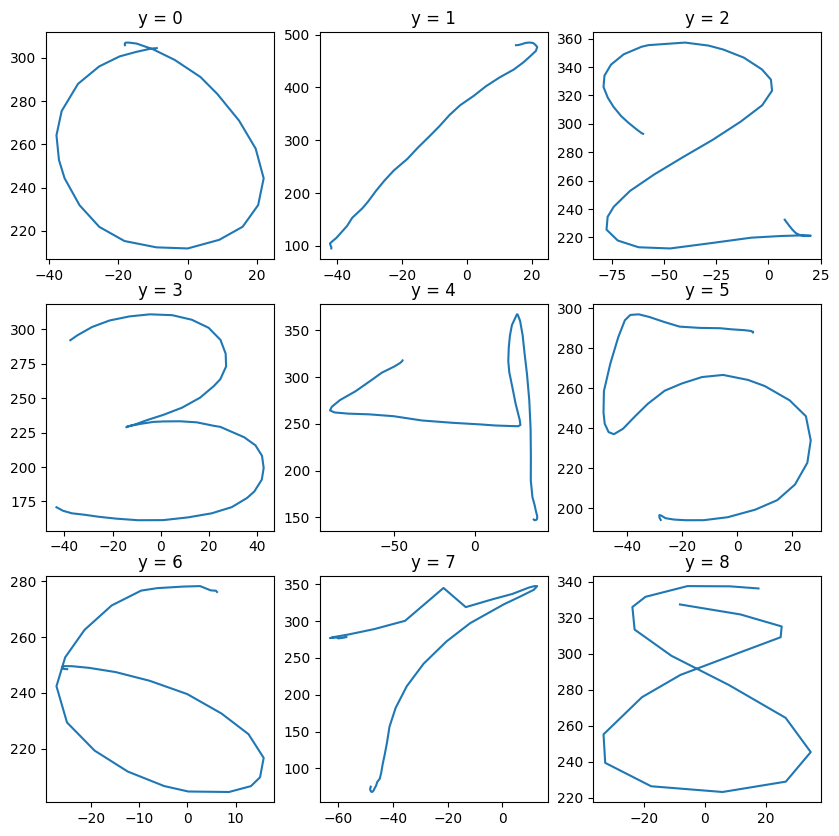

In [189]:
# https://stackoverflow.com/questions/37971541/how-does-the-indexing-of-subplots-work

# Function to plot some time-series samples in xy-coordinates
def plotsubplots(X_train, stop=900, spacing=100):
    fig = plt.figure(figsize=(10, 10))

    k = -1 # Indexing number for subplots

    for i in range(0, stop, spacing):

        k += 1
        X = X_train[i]
        ax = fig.add_subplot(3, 3, k + 1)
        ax.plot(X[:,0], X[:,1])
        plt.title(f'y = {y_train[i]}')


plotsubplots(X_train)

#### Principal Component Analysis (PCA)


1. Data standardization
2. Eigenvalues and -vectors
3. Projection

In [ ]:
# https://en.wikipedia.org/wiki/Principal_component_analysis
# https://jonathan-hui.medium.com/machine-learning-singular-value-decomposition-svd-principal-component-analysis-pca-1d45e885e491

X_train_std = [] # Standardized training data
eigenvalues = []
eigenvectors = []
T_train = [] # Projection training data

# print(X_train)

for i in range(len(X_train)):


    X = X_train[i]
   

    # Standardization Z = (X-µ) / σ
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=1)
    Z = (X - mu) / sigma
    X_train_std.append(Z)

    # Number of samples
    n = Z.shape[0]    

    # SVD
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)


    D = S**2 / (n -1) # Eigenvalues
    # print(D.shape)
    V = Vt.T # Eigenvectors

    k = 2 # Truncation value
    explain_ratio = D[:k].sum() / D.sum()
    print(f'{k} singular values explain {explain_ratio*100:.4f} % of the sample variance.')


    eigenvalues.append(D)
    eigenvectors.append(V)

    # Projection T = ZV = US
    T = Z @ V
    T_train.append(T)

    # print(f'Mean of the Z: {Z.mean():.4f}') # Should be 0
    # print(F'Standard deviation of the Z: {Z.std():.4f}') # Should be 1


# print(T_train[0].shape)


2 singular values explain 95.3521 % of the sample variance.
2 singular values explain 91.5501 % of the sample variance.
2 singular values explain 96.8274 % of the sample variance.
2 singular values explain 96.4644 % of the sample variance.
2 singular values explain 81.6201 % of the sample variance.
2 singular values explain 87.1070 % of the sample variance.
2 singular values explain 98.7233 % of the sample variance.
2 singular values explain 98.1350 % of the sample variance.
2 singular values explain 81.0706 % of the sample variance.
2 singular values explain 99.3690 % of the sample variance.
2 singular values explain 97.4866 % of the sample variance.
2 singular values explain 84.8816 % of the sample variance.
2 singular values explain 94.2400 % of the sample variance.
2 singular values explain 98.3991 % of the sample variance.
2 singular values explain 75.9901 % of the sample variance.
2 singular values explain 80.4565 % of the sample variance.
2 singular values explain 90.1441 % of t

The  data plots should be now standardized and centered in the origon

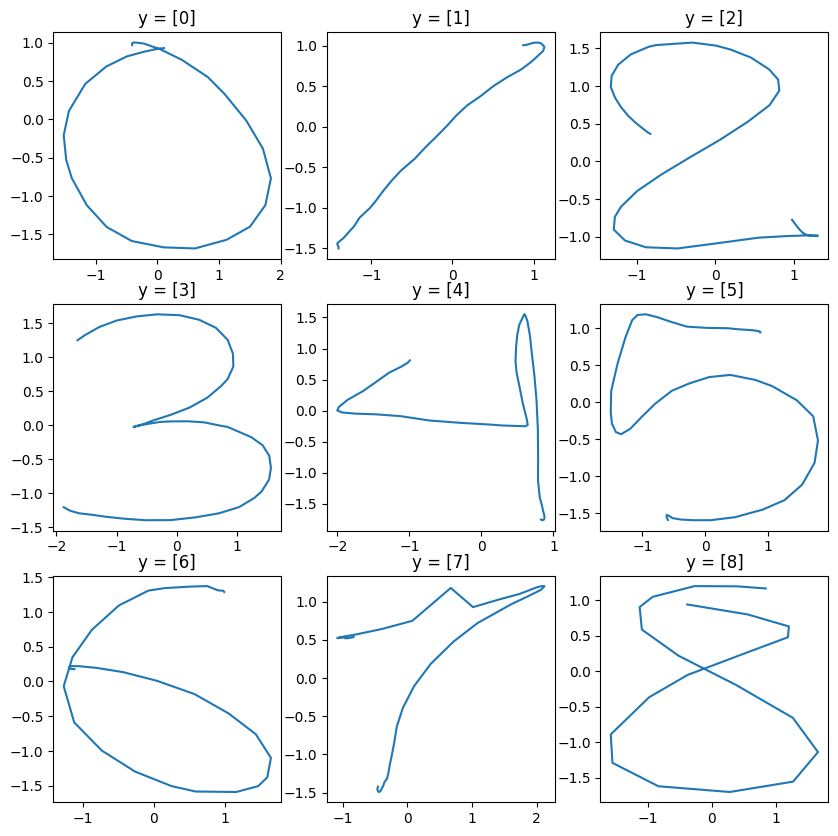

In [158]:
plotsubplots(X_train_std)

Extracting features from the training data and making a new dataset to see if there is anything interesting

In [ ]:

new_X_train = []

# Extracting features from the previous training data and making a simpler dataset with class labels
for i in range(len(X_train)):

    x = X_train[i]
    sum = x.sum()
    mean = x.mean()
    median = np.median(x)
    std = x.std()
    max = x.max()
    min = x.min()

    X = [sum, mean, median, std, max, min]
    new_X_train.append(X)



# new_X_train
y_train = np.array(y_train).reshape(-1, 1)
data_matrix = np.array(new_X_train)
data_matrix = np.hstack((data_matrix, y_train))
data_matrix



array([[ 7.72392073e+03,  8.04575076e+01, -1.32040000e+01, ...,
         3.06990000e+02, -3.77970000e+01,  0.00000000e+00],
       [ 7.25432921e+03,  7.11208746e+01,  2.90510000e+00, ...,
         2.90370000e+02, -3.58330000e+01,  0.00000000e+00],
       [ 6.33684673e+04,  9.60128292e+01, -1.37820000e+01, ...,
         5.56890000e+02, -1.41500000e+02,  0.00000000e+00],
       ...,
       [ 9.97718660e+03,  8.11153382e+01,  6.21550000e+00, ...,
         3.52330000e+02, -5.72570000e+01,  9.00000000e+00],
       [ 1.14617523e+04,  7.64116820e+01,  1.01945000e+01, ...,
         3.40790000e+02, -5.81790000e+01,  9.00000000e+00],
       [ 7.64143577e+03,  7.27755788e+01, -3.18920000e+00, ...,
         2.75500000e+02, -3.10570000e+01,  9.00000000e+00]],
      shape=(1000, 7))

New dataset:

In [177]:
data = pd.DataFrame(data_matrix)
columns = ['sum', 'mean','median', 'std', 'max', 'min', 'class']
data.columns = columns


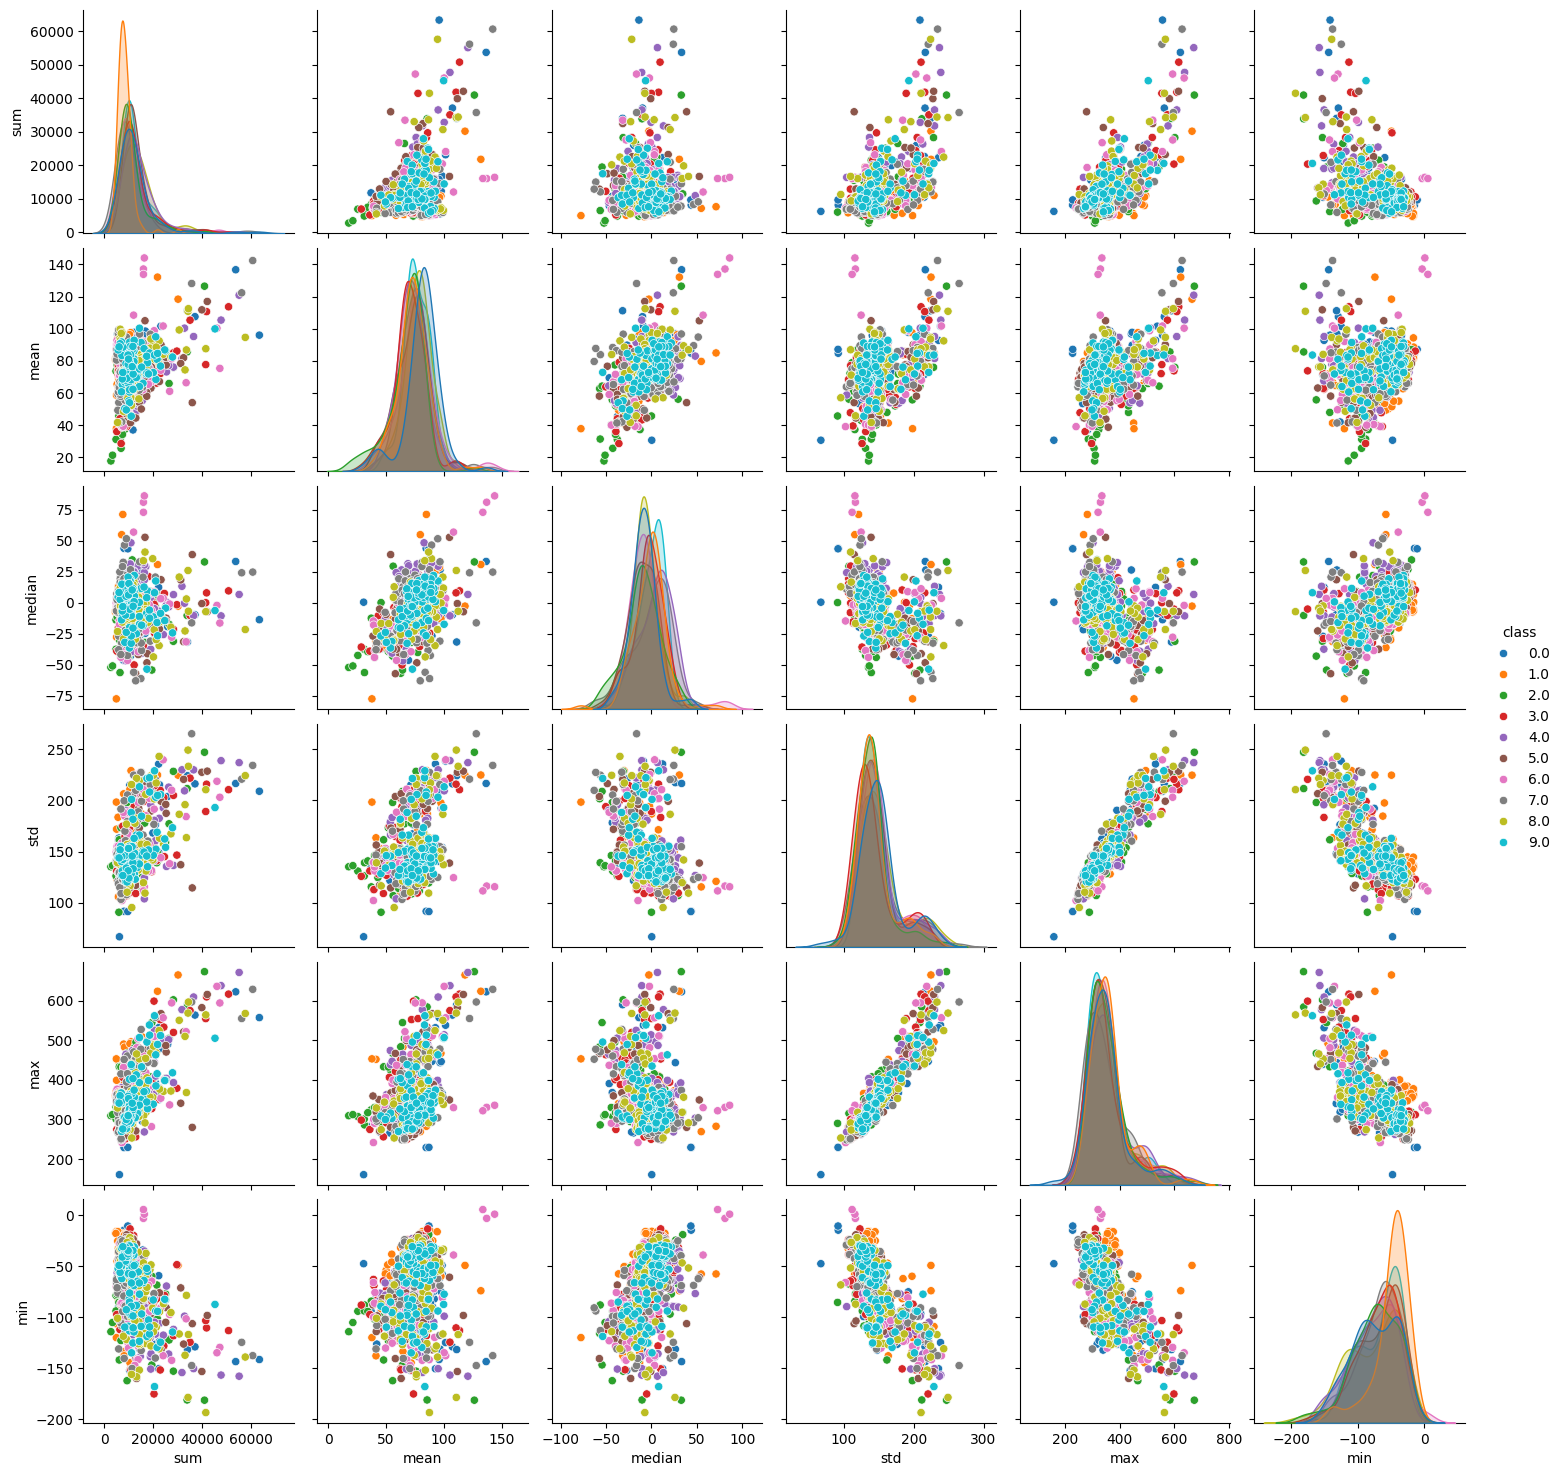

In [178]:
sns.pairplot(data, hue='class', palette='tab10');

#### Thoughts
All the data points are quite stacked, but probably many classifiers can still handle it. Although, there is no need to use this dataset, since time series data should suffice. PCA might also be unnecessary since we only have 3D data, so the dimensionality is not the problem. Probably, developing some kind of time series classifier is worth looking into now.